# Figure 1

Params: 

$\lambda_0 = 900 $ nm, 

$\alpha = 25 $ deg, 

$\psi = \pi/2$, 

$\chi=\pi/8$, 

$d=2$ nm, 

$R=[100,165]$ nm

## Scattering cross section from $\lambda$, R=147.5 nm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sigma_sc = np.loadtxt('article_data_plots/sigma_air_sigma_sc_wl_295nm_circ_pol.txt', skiprows=0, delimiter=',')

plt.figure(figsize=(4,2.5), dpi=300)
plt.plot(sigma_sc[:,0], sigma_sc[:,2], label='SPP', color='orange', lw=3)
plt.plot(sigma_sc[:,0], sigma_sc[:,1], label='Air', color='blue', lw=3)
plt.plot(sigma_sc[:,0], sigma_sc[:,1]+sigma_sc[:,2], label='Total', lw=3, c='black')
plt.ylabel(r'$\sigma_{sc}$, norm')
plt.xlabel('$\\lambda$, nm')
plt.grid()
plt.legend(loc='lower left')
plt.xlim(sigma_sc[0,0], sigma_sc[-1,0])
plt.ylim(0,22)
#plt.savefig('article_plots/scat_sc_air_spp.svg', bbox_inches='tight')
plt.show()

## Scattering cross section from R, $\lambda=900$ nm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sigma_sc = np.loadtxt('article_data_plots/sigma_air_sigma_sc_R_900nm_circ_pol.txt', skiprows=0, delimiter=',')

plt.figure(figsize=(4,2.5), dpi=300)
plt.plot(sigma_sc[:,0], sigma_sc[:,2]/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='SPP', color='orange', lw=3)
plt.plot(sigma_sc[:,0], sigma_sc[:,1]/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='Air', color='blue', lw=3)
plt.plot(sigma_sc[:,0], (sigma_sc[:,1]+sigma_sc[:,2])/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='Total', lw=3, c='black')

# plt.plot(sigma_sc[:,0], (sigma_sc[:,1]+sigma_sc[:,2])/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='numerical', lw=3, c='black', ls='--')

# plt.plot(R, (sigma_MD+sigma_ED)/(np.pi*(R*1e-9)**2), label='analytical', color='black', lw=3)

plt.ylabel(r'$\sigma_{sc}$, norm')
plt.xlabel('$R$, nm')
plt.grid()
plt.legend(loc='upper right')
plt.xlim(sigma_sc[0,0], sigma_sc[-26,0])
# plt.ylim(0,22)
#plt.savefig('article_plots/scat_sc_air_spp_fromR.svg', bbox_inches='tight')
plt.show()

## 3D plot check in `3D_plot.ipynb`

## SPP Heatmap

In [11]:
from MieSppForce.simulation import SimulationConfig, SweepRunner,  DipoleCalculator, OpticalForceCalculator, DiagramCalculator, CylindricalGrid, SphericalGrid, DiagramResult
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()


def get_mean_angle(I, phi):
    vec_sum = np.sum(I * np.exp(1j * phi))
    return np.angle(vec_sum)
    
def get_maximum_direction(diag):
    import numpy as np
    from scipy.spatial import ConvexHull

    n = np.column_stack([
        np.sin(diag.theta) * np.cos(diag.phi),
        np.sin(diag.theta) * np.sin(diag.phi),
        np.cos(diag.theta)
    ])

    hull = ConvexHull(n)
    dOmega = np.zeros(len(n))

    for tri in hull.simplices:
        a, b, c = n[tri]
        num = abs(np.dot(a, np.cross(b, c)))
        den = 1 + np.dot(a, b) + np.dot(b, c) + np.dot(c, a)
        Omega = 2 * np.arctan2(num, den)
        dOmega[tri] += Omega / 3

    Px = np.sum(diag.D * n[:, 0] * dOmega)
    Py = np.sum(diag.D * n[:, 1] * dOmega)
    Pz = np.sum(diag.D * n[:, 2] * dOmega)

    phi_eff = np.arctan2(Py, Px)
    theta_eff = np.arctan2(np.sqrt(Px ** 2 + Py ** 2), Pz)
    return theta_eff, phi_eff


base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  110.5 * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi = np.pi/2,
    chi = np.pi/4,
    show_warnings=False,
    initial_field_type='plane_wave'
)

num_points = 100

XOY_SPP = CylindricalGrid(phi=np.linspace(0, 2*np.pi, 100)*ureg.rad, 
                          z=0*ureg.nm, 
                          r=base_config.wl*5)

XOY_AIR = SphericalGrid(
    r= base_config.wl,
    theta = np.linspace(0, np.pi/2, 20) * ureg.rad,
    phi = np.linspace(0, 2*np.pi, 100) * ureg.rad
)

In [13]:
sweep_spp, diagrams_spp, _ = SweepRunner(base_config, 'R', np.linspace(100, 165, num_points)*ureg.nm, True, True, True, False, XOY_SPP, 'spp').run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

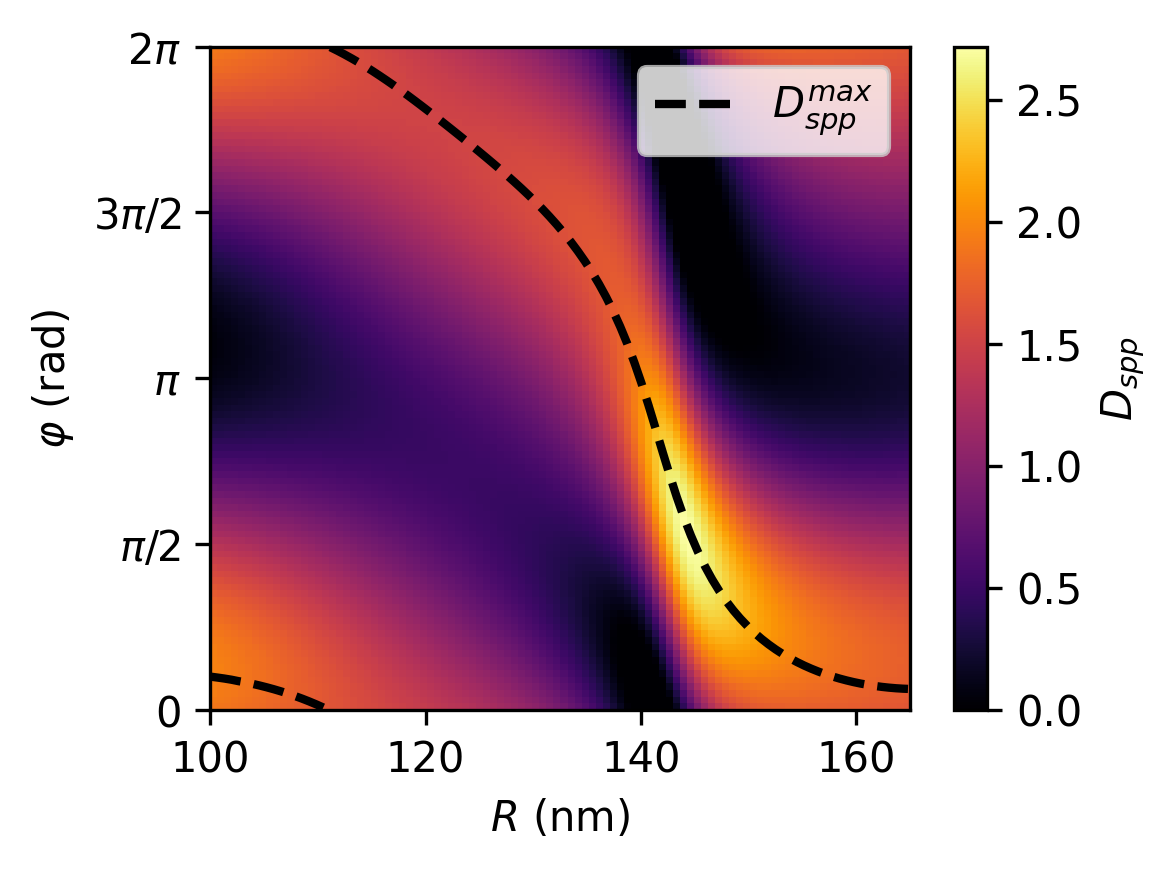

In [19]:
import numpy as np
import matplotlib.pyplot as plt

diagrams_spp["phi"] = diagrams_spp["phi"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)
diagrams_spp["R"]  = diagrams_spp["R"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)

pivot = diagrams_spp.pivot(index="phi", columns="R", values="D")

plt.figure(figsize=(4, 3), dpi=300)

plt.imshow(
    pivot.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot.columns.min()), float(pivot.columns.max()),
        float(pivot.index.min()),   float(pivot.index.max())
    ],
    cmap="inferno",
    vmin=0,
)

phi_values = pivot.index.values.astype(float)
R_values = pivot.columns.values.astype(float)
max_phi_for = []

for r in R_values:
    col = pivot[r].values.astype(float)
    complex_sum = np.sum(col * np.exp(1j * phi_values))
    phi_mean = np.angle(complex_sum)
    if phi_mean < 0:
        phi_mean += 2 * np.pi
    max_phi_for.append(phi_mean)


ind_stop = 17

plt.plot(R_values[:ind_stop], max_phi_for[:ind_stop], color="black", linewidth=2, label="$D_{spp}^{max}$", ls='--')

plt.plot(R_values[ind_stop:], max_phi_for[ind_stop:], color="black", linewidth=2, ls='--')



plt.colorbar(label="$D_{spp}$")
plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")

yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$"]



plt.yticks(yticks, yticklabels)
plt.ylim(0, 2*np.pi)
plt.tight_layout()
plt.legend()
# plt.savefig('article_plots/Dspp_map_R.svg', dpi=300)
# plt.savefig('article_plots/Dspp_map_R.png', dpi=300)
plt.show()


## Air heatmap

In [14]:
sweep_reg, diagrams_reg, _ = SweepRunner(base_config, 'R', np.linspace(100, 165, num_points)*ureg.nanometer, True, True, True, False, XOY_AIR, 'reg', diagram_normalize=None).run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

/Users/semyon_b/git/SPP_ANALYTICAL/MieSppForce/green_func_v2.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  lambda kr: rs(kr)*kr*k/kz(kr)*exp_fac(kr)*jn(2, kr*k*r),  # 4
/Users/semyon_b/git/SPP_ANALYTICAL/MieSppForce/green_func_v2.py:81: RuntimeWarning: invalid value encountered in scalar multiply
  lambda kr: rs(kr)*kr*k/kz(kr)*exp_fac(kr)*jn(2, kr*k*r),  # 4


In [21]:
import numpy as np
import pandas as pd

def integrate_pattern_over_theta(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    theta_col: str = "theta",
    R_col: str = "R",
    D_col: str = "D",
) -> pd.DataFrame:
    """
    Интегрирует 3D диаграмму D(phi, theta) по theta:
        p(phi, R) = ∫_{theta_min}^{theta_max} D(phi, theta, R) * sin(theta) dtheta

    Возвращает DataFrame с колонками: [R, phi, p]
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[theta_col] = df[theta_col].apply(_to_float)
    df[R_col] = df[R_col].apply(_to_float)
    df[D_col] = df[D_col].apply(_to_float)

    df = df.sort_values([R_col, phi_col, theta_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        th = g[theta_col].to_numpy()
        D = g[D_col].to_numpy()
        y = D * np.sin(th)
        return float(np.trapezoid(y, th))

    out = (
        df.groupby([R_col, phi_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out

In [22]:
import numpy as np
import pandas as pd

def normalize_over_phi_per_R(
    df_phiR: pd.DataFrame,
    *,
    R_col: str = "R",
    phi_col: str = "phi",
    I_col: str = "p",          # сюда подайте результат интегрирования по theta
    out_col: str = "D_norm",   # имя нормированной колонки
) -> pd.DataFrame:
    """
    Нормировка для каждого R:
        D_norm(phi, R) = 2π * I(phi, R) / ∫_0^{2π} I(phi, R) dphi
    где I(phi, R) — уже проинтегрированная по theta величина (например, p).
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = df_phiR.copy()

    df = df.sort_values([R_col, phi_col])

    def _norm_group(g: pd.DataFrame) -> pd.DataFrame:
        phi = g[phi_col].to_numpy(dtype=float)
        I = g[I_col].to_numpy(dtype=float)

        denom = float(np.trapezoid(I, phi))
        if not np.isfinite(denom) or abs(denom) < 1e-30:
            g[out_col] = np.nan
            return g

        g[out_col] = (2.0 * np.pi) * I / denom
        return g

    return df.groupby(R_col, group_keys=False).apply(_norm_group)

# использование:
diagrams_reg_phiR = integrate_pattern_over_theta(diagrams_reg)   # -> колонки [R, phi, p]
diagrams_reg_phiR_norm = normalize_over_phi_per_R(diagrams_reg_phiR, I_col="p", out_col="D")
pivot = diagrams_reg_phiR_norm.pivot(index="phi", columns="R", values="D")

/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_38478/3985244157.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _integrate_group(g))
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_38478/2202535655.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(R_col, group_keys=False).apply(_norm_group)


In [23]:
def get_max_direction(result: DiagramResult):  
    data = pd.DataFrame({"phi": result.phi, "theta": result.theta, "D": result.D})
    phi_u = np.sort(data["phi"].unique())
    theta_u = np.sort(data["theta"].unique())
    pivot = data.pivot_table(index="theta", columns="phi", values="D", aggfunc='mean')

    pivot = pivot.reindex(index=theta_u, columns=phi_u)
    D_grid = pivot.values

    PHI, THETA = np.meshgrid(phi_u, theta_u, indexing='xy')
    X = D_grid * np.sin(THETA)**2 * np.cos(PHI)
    Y = D_grid * np.sin(THETA)**2 * np.sin(PHI)
    Z = D_grid * np.cos(THETA)*np.sin(THETA)
    
    Px_phi = np.trapezoid(X, phi_u, axis=1)
    Py_phi = np.trapezoid(Y, phi_u, axis=1)
    Pz_phi = np.trapezoid(Z, phi_u, axis=1)

    Px = np.trapezoid(Px_phi, theta_u)
    Py = np.trapezoid(Py_phi, theta_u)
    Pz = np.trapezoid(Pz_phi, theta_u)
    
    phi_eff = np.arctan2(Py, Px)
    theta_eff = np.arctan2(np.sqrt(Px**2 + Py**2), Pz)
    
    return [Px, Py, Pz], [phi_eff, theta_eff]

results_phi_max_air = []
for r_val, group in diagrams_reg.groupby("R"):
    diag = DiagramResult(
        phi=group["phi"].values.astype(float),
        theta=group["theta"].values.astype(float),
        D=group["D"].values.astype(float)
    )
    _, [phi_eff, theta_eff] = get_max_direction(diag)
    results_phi_max_air.append({"R": r_val, "phi_eff": phi_eff, "theta_eff": theta_eff})

phi_air_diag = pd.DataFrame(results_phi_max_air)

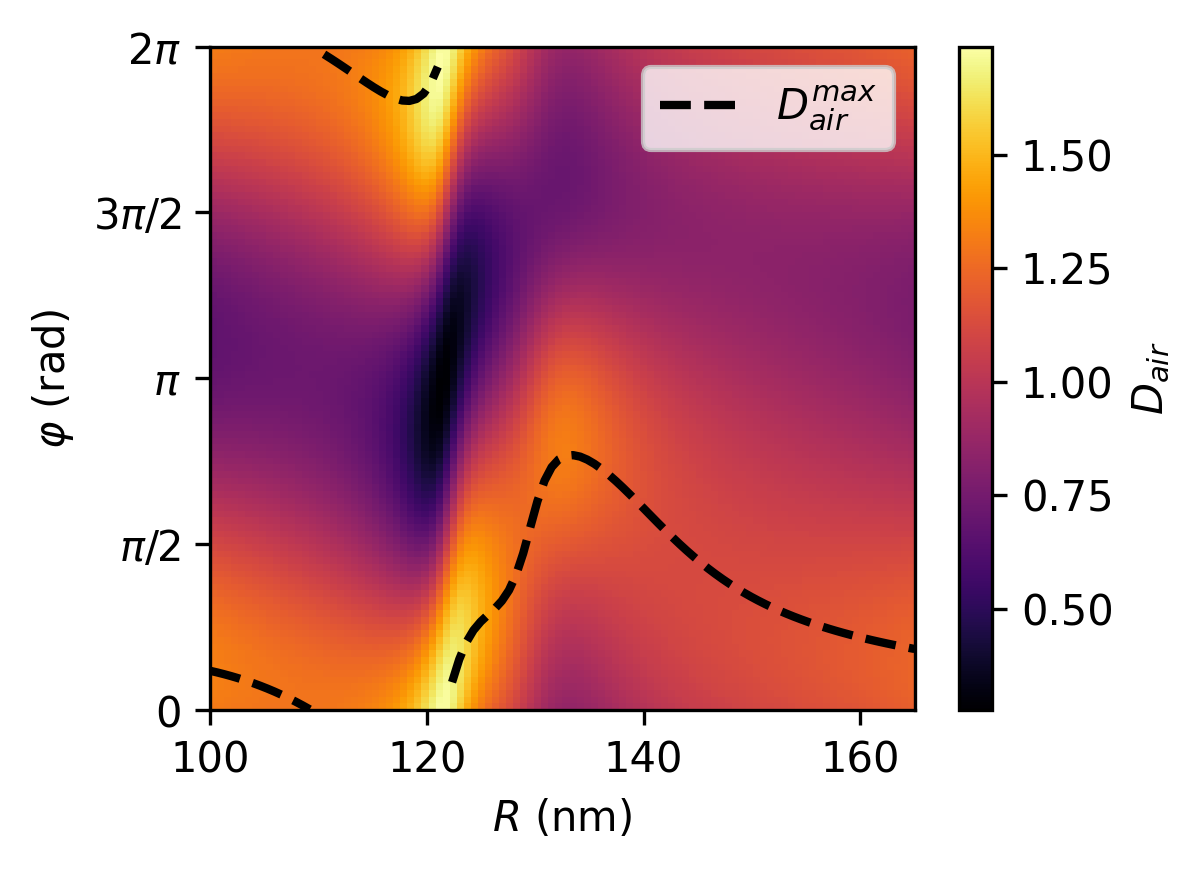

In [24]:
import numpy as np
import matplotlib.pyplot as plt


R_values = pivot.columns.values.astype(float)
phi_values = pivot.index.values.astype(float)

plt.figure(figsize=(4, 3), dpi=300)
plt.imshow(
    pivot.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot.columns.min()), float(pivot.columns.max()),
        float(pivot.index.min()),   float(pivot.index.max())
    ],
    cmap="inferno",
)


phi_unwraped = np.asarray([i + np.pi*2 if i<0 else i for i in phi_air_diag.phi_eff ])

phi_max = np.asarray(phi_unwraped, dtype=float)
dphi = np.abs(np.diff(phi_max))
breaks = dphi > np.pi

phi_plot = phi_max.copy()
phi_plot[1:][breaks] = np.nan

plt.plot(R_values, phi_plot, color="black", linewidth=2, label="$D_{air}^{max}$", ls='--')

plt.colorbar(label="$D_{air}$")
plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")

yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$"]
plt.yticks(yticks, yticklabels)

plt.legend(loc="upper right")
plt.tight_layout()
# plt.savefig('article_plots/Dair_R_hot.svg', dpi=300)
# plt.savefig('article_plots/Dair_R_hot.png', dpi=300)
plt.show()

# Figure 2

## angle D spp vs Fspp

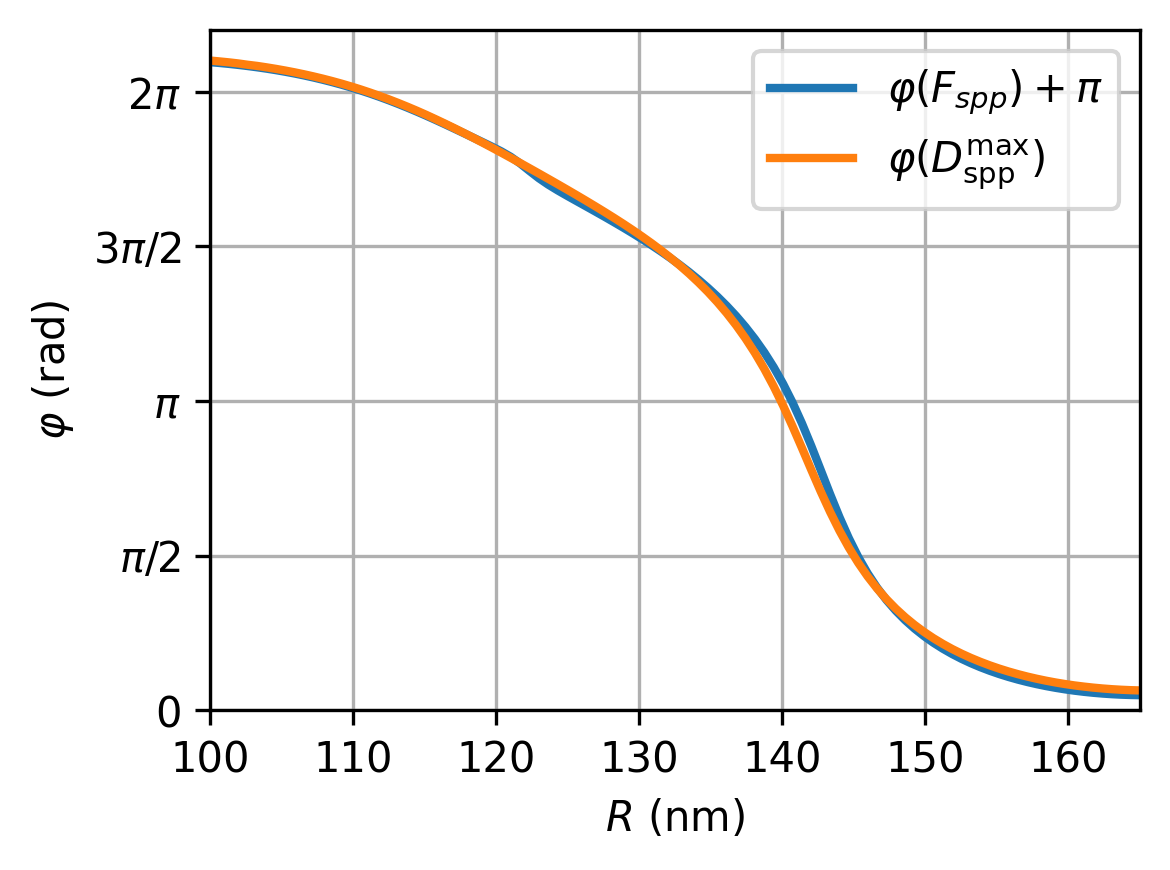

In [25]:
Fx_spp = sweep_reg.Fxspp 
Fy_spp = sweep_reg.Fyspp

Fx_spp = Fx_spp.apply(lambda x: x.magnitude).to_numpy()
Fy_spp = Fy_spp.apply(lambda x: x.magnitude).to_numpy()

phi_F_spp = np.arctan2(Fy_spp, Fx_spp)

plt.figure(figsize=(4,3), dpi=300)

plt.plot(sweep_reg.R, np.unwrap(phi_F_spp)+np.pi+2*np.pi, label="$\\varphi(F_{spp}) + \\pi$", lw=2)


plt.plot(sweep_reg.R, np.unwrap(max_phi_for)+np.pi*2, label="$\\varphi(D_{\\text{spp}}^{\\text{max}})$", lw=2)

plt.ylim(0,2*np.pi*1.1)

yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$", "$3 \\pi/2$", "$2\\pi$"]
plt.yticks(yticks, yticklabels)

plt.xlim(sweep_reg.R.min().magnitude, sweep_reg.R.max().magnitude)

plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('article_plots/phi_vs_R_spp.svg', dpi=300)
plt.savefig('article_plots/phi_vs_R_spp.png', dpi=300)
plt.show()

## angle D air vs F 

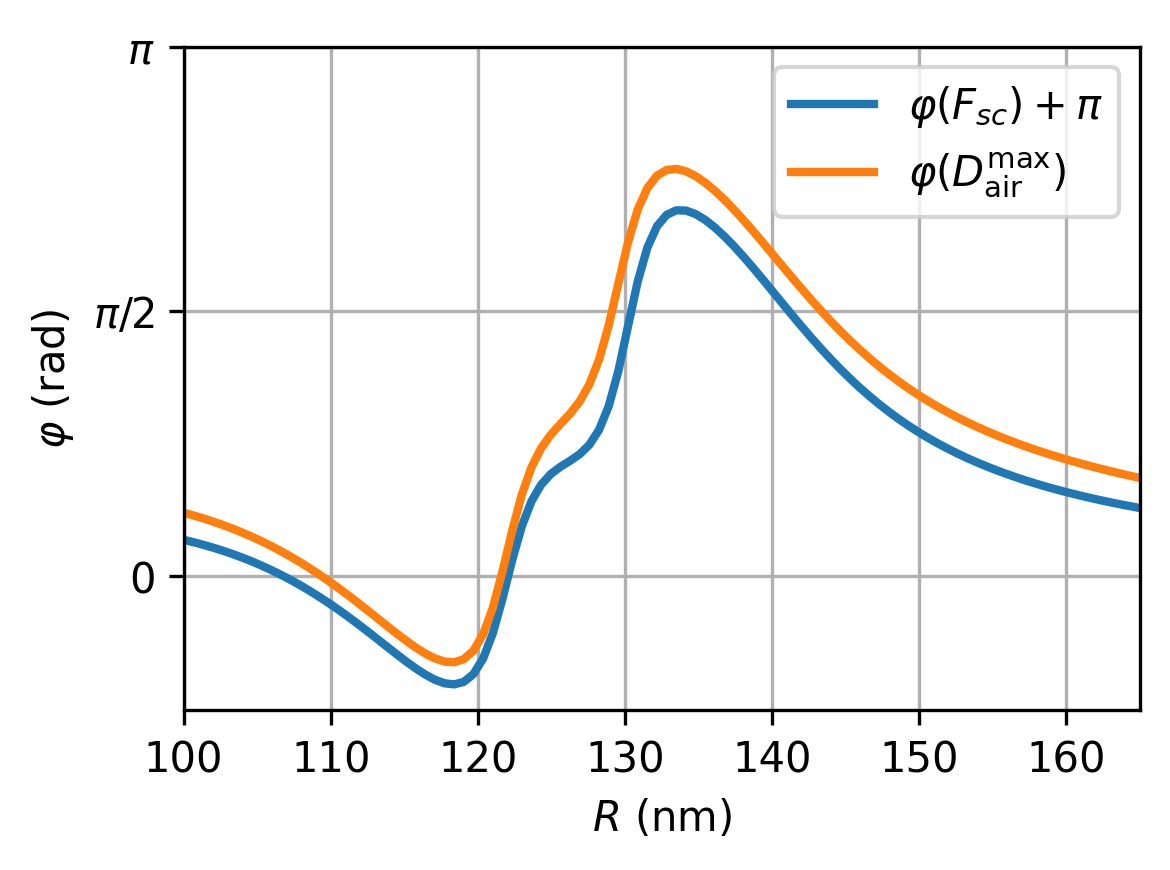

In [20]:
Fx_sc = sweep_reg.Fx - sweep_reg.Fxe0 - sweep_reg.Fxm0 - sweep_reg.Fxspp
Fy_sc = sweep_reg.Fy - sweep_reg.Fyspp

Fx_sc = Fx_sc.apply(lambda x: x.magnitude).to_numpy()
Fy_sc = Fy_sc.apply(lambda x: x.magnitude).to_numpy()

phi_F_sc = np.arctan2(Fy_sc, Fx_sc)

plt.figure(figsize=(4,3), dpi=300)

plt.plot(sweep_reg.R, np.unwrap(phi_F_sc)+np.pi, label="$\\varphi(F_{sc}) + \\pi$", lw=2)


plt.plot(sweep_reg.R, phi_air_diag.phi_eff, label="$\\varphi(D_{\\text{air}}^{\\text{max}})$", lw=2)

yticks = [0, np.pi/2, np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$"]
plt.yticks(yticks, yticklabels)

plt.xlim(sweep_reg.R.min().magnitude, sweep_reg.R.max().magnitude)

plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('article_plots/phi_vs_R_air.svg', dpi=300)
plt.savefig('article_plots/phi_vs_R_air.png', dpi=300)
plt.show()

## Fx - Fx spp and Fx sc

In [27]:

base_config_free_space = SimulationConfig(
    wl = base_config.wl,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(0),
    psi = 0,
    chi = 0,
    show_warnings=False,
    substrate = 'Air',
    initial_field_type='plane_wave',
)

sweep_res_free_space, _, _ = SweepRunner(base_config_free_space, 'R', np.linspace(100, 160, 185)*ureg.nanometer, True, False, True, False).run()

F0 = np.max(np.abs(sweep_res_free_space['Fz'].to_numpy()))

  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/185 [00:00<?, ?it/s]

In [29]:
from MieSppForce.force import field_dx
from MieSppForce.dipoles import initial_field
from MieSppForce import frenel

mu0_const = base_config.mu0_const.magnitude

f_coms_tot = np.loadtxt('fx_fy_circ_900_fromR.txt', delimiter=',', skiprows=8)
p_coms = np.loadtxt('p_circ_900_fromR.txt', delimiter=',', skiprows=8) 
m_coms = np.loadtxt('m_circ_900_fromR.txt', delimiter=',', skiprows=8) 

px = p_coms[:,1] - 1j* p_coms[:,2] 
py = p_coms[:,3] - 1j* p_coms[:,4] 
pz = p_coms[:,5] - 1j* p_coms[:,6] 

mx = m_coms[:,1] - 1j* m_coms[:,2] 
my = m_coms[:,3] - 1j* m_coms[:,4] 
mz = m_coms[:,5] - 1j* m_coms[:,6] 

epsAu = frenel.get_interpolate('Au')
dist = 2

R_coms = p_coms[:,0]

dEdx = np.zeros((len(R_coms), 3), dtype=complex)
dHdx = np.zeros((len(R_coms), 3), dtype=complex)

for i in range(len(R_coms)):
    dEdx[i,:], dHdx[i,:] = field_dx(initial_field, 900, np.deg2rad(25), 1, epsAu, point=[0,0,dist+R_coms[i]], phase=np.pi/2, a_angle=np.pi/4)
    
Fx_press_e = 0.5*np.real( px.conj() * dEdx[:,0] + py.conj() * dEdx[:,1] + pz.conj() * dEdx[:,2] )

Fx_press_m = 0.5*np.real( mx.conj() * dHdx[:,0] + my.conj() * dHdx[:,1] + mz.conj() * dHdx[:,2] )*mu0_const

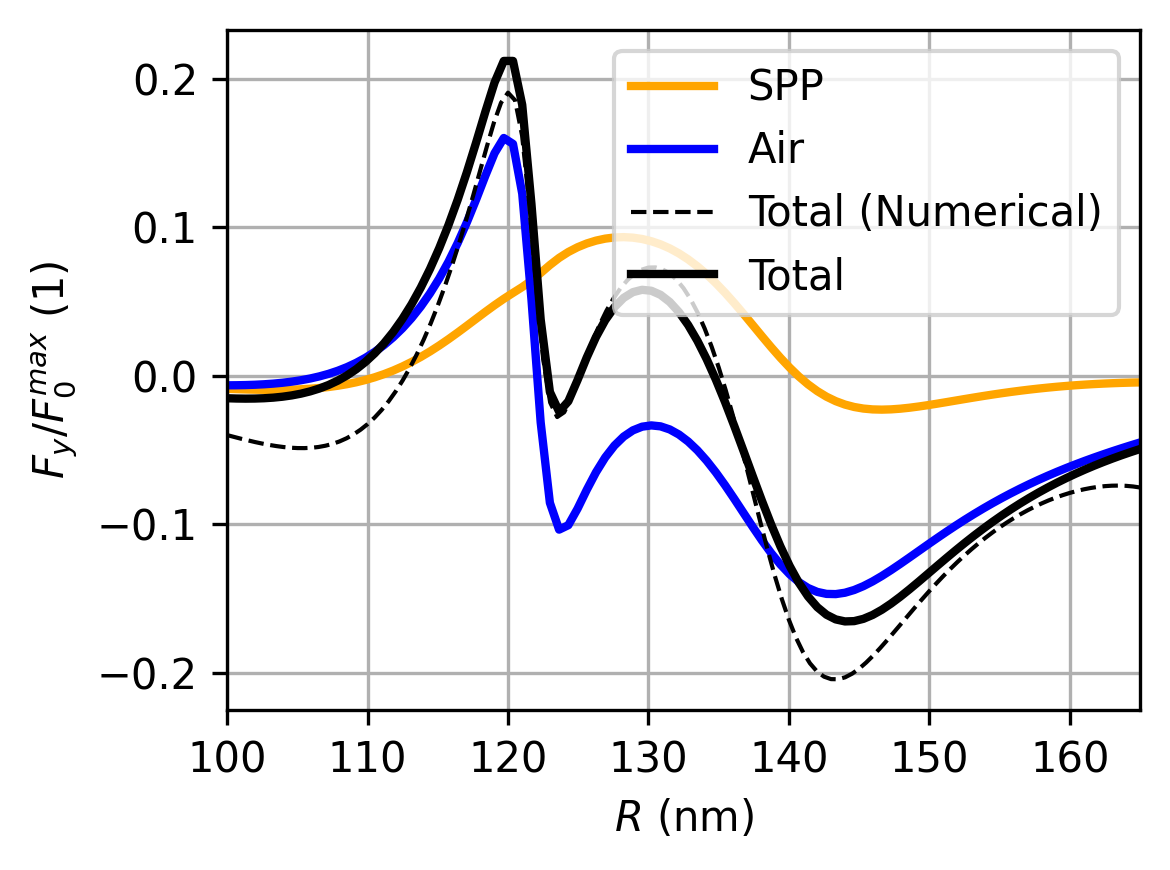

In [54]:
plt.figure(figsize=(4,3), dpi=300)

Fyspp = sweep_spp.Fyspp.apply(lambda x: x.magnitude).to_numpy()
Fy = sweep_spp.Fy.apply(lambda x: x.magnitude).to_numpy()
Fy_sc = sweep_reg.Fy.apply(lambda x: x.magnitude).to_numpy() - sweep_reg.Fyspp.apply(lambda x: x.magnitude).to_numpy()

plt.plot(sweep_spp.R, Fyspp/F0, label="SPP", c='orange', lw=2)
plt.plot(sweep_spp.R, Fy_sc/F0, label="Air", c='blue', lw=2)
plt.plot(f_coms_tot[:,0], f_coms_tot[:,2]/F0, label="Total (Numerical)", c='black', lw=1, ls='--')
plt.plot(sweep_spp.R, Fy/F0, label="Total", c='black', lw=2)

plt.xlim(sweep_spp.R.to_numpy()[0], sweep_spp.R.to_numpy()[-1])
plt.xlabel("$R$ (nm)")
plt.ylabel("$F_y/F_0^{max}$ (1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('article_plots/Fy_vs_R_air.svg', dpi=300)

plt.show()

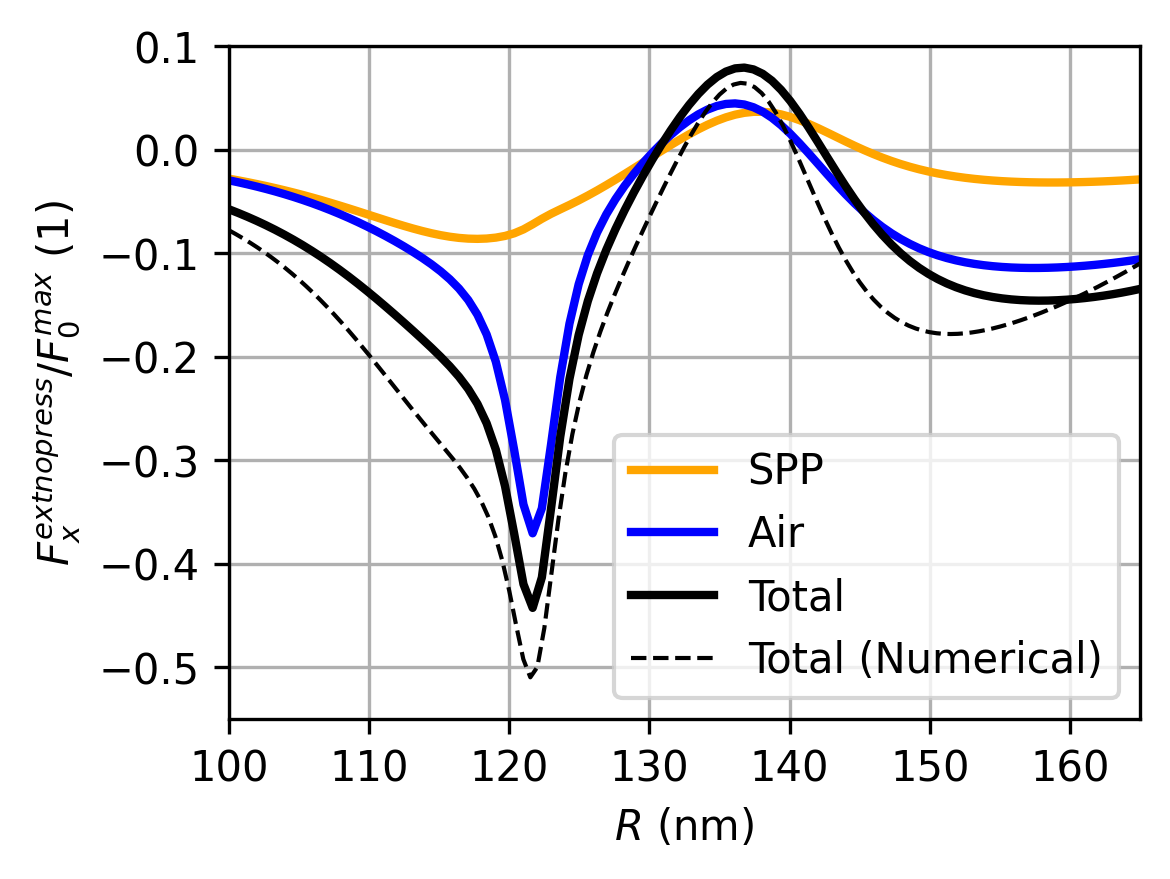

In [53]:
plt.figure(figsize=(4,3), dpi=300)

Fxspp = sweep_spp.Fxspp.apply(lambda x: x.magnitude).to_numpy()
Fx = sweep_spp.Fx.apply(lambda x: x.magnitude).to_numpy() - sweep_reg.Fxe0.apply(lambda x: x.magnitude).to_numpy() - sweep_reg.Fxm0.apply(lambda x: x.magnitude).to_numpy()
Fx_sc = Fx - Fxspp


plt.plot(sweep_spp.R, Fxspp/F0, label="SPP", c='orange', lw=2)
plt.plot(sweep_spp.R, Fx_sc/F0, label="Air", c='blue', lw=2)
plt.plot(sweep_spp.R, Fx/F0, label="Total", c='black', lw=2)


plt.plot(f_coms_tot[:,0], (f_coms_tot[:,1]-Fx_press_e-Fx_press_m)/F0, label="Total (Numerical)", c='black', lw=1, ls='--')


plt.xlim(sweep_spp.R.to_numpy()[0], sweep_spp.R.to_numpy()[-1])
plt.xlabel("$R$ (nm)")
plt.ylabel("$F_x^{\text{no press}}/F_0^{max}$ (1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-0.55, 0.1)
plt.savefig('article_plots/Fx_vs_R_air.svg', dpi=300)

plt.show()

# Figure 3

## Fy from psi and chi

In [2]:
from MieSppForce.simulation import SimulationConfig, SweepRunner2D
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()


chi_values = np.linspace(-np.pi/4,  np.pi/4, 200)
psi_values = np.linspace(0, np.pi, 200)

base_config_R_psi = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=122*ureg.nm,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(25),
    chi = chi_values[0],
    psi = psi_values[0],
    show_warnings=False,
    initial_field_type='plane_wave',
)



runner_chi_psi = SweepRunner2D(
    base_config_R_psi,
    primary_param="chi",
    primary_values=chi_values,
    secondary_param="psi",
    secondary_values=psi_values,
    compute_dipoles=True,
    compute_diagram=False,
    compute_force=True,
    compute_fields=False,
    parallel_param="primary",
    enable_parallel=False
)

df_sweep_chi_psi, _, _ = runner_chi_psi.run(n_jobs=-1)
df_sweep_chi_psi.head()

/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
chi sweep: 100%|██████████| 200/200 [01:38<00:00,  2.04it/s]


,chi,psi,px,py,pz,mx,my,mz,Fx,Fxe0,...,Fxsppe1,Fxsppe2,Fxsppm1,Fxsppm2,Fyspp,Fysppe1,Fysppe2,Fysppm1,Fysppm2,Fzspp
0,-0.785398,0.000000,(1.608522711526611e-31-1.0066102296673539e-31j...,(-1.305638073927552e-31-1.6510738189044528e-31...,(2.2417815079641356e-32+6.659405336372075e-32j...,(6.821092798747961e-23+4.5289980065357625e-23j...,(4.298706800275342e-23-6.846214109203028e-23j)...,(2.6193355943051857e-23-1.783237028770596e-22j...,7.091544854915048e-25 newton,4.8421354538328875e-25 newton,...,-2.247785601407706e-26 newton,1.9948386782086853e-25 newton,1.3028103288650726e-26 newton,-3.1250971372849067e-25 newton,-1.177441669085019e-25 newton,8.6549980738079e-27 newton,3.364056291440111e-25 newton,5.730798463736037e-27 newton,-4.6853559259005685e-25 newton,1.339423139260723e-24 newton
1,-0.785398,0.015787,(1.608522711526611e-31-1.0066102296673539e-31j...,(-1.305638073927552e-31-1.6510738189044528e-31...,(2.2417815079641356e-32+6.659405336372075e-32j...,(6.821092798747961e-23+4.5289980065357625e-23j...,(4.298706800275342e-23-6.846214109203028e-23j)...,(2.6193355943051857e-23-1.783237028770596e-22j...,7.091544854915048e-25 newton,4.8421354538328875e-25 newton,...,-2.247785601407706e-26 newton,1.9948386782086853e-25 newton,1.3028103288650726e-26 newton,-3.1250971372849067e-25 newton,-1.177441669085019e-25 newton,8.6549980738079e-27 newton,3.364056291440111e-25 newton,5.730798463736037e-27 newton,-4.6853559259005685e-25 newton,1.339423139260723e-24 newton
2,-0.785398,0.031574,(1.608522711526611e-31-1.0066102296673539e-31j...,(-1.305638073927552e-31-1.6510738189044528e-31...,(2.2417815079641356e-32+6.659405336372075e-32j...,(6.821092798747961e-23+4.5289980065357625e-23j...,(4.298706800275342e-23-6.846214109203028e-23j)...,(2.6193355943051857e-23-1.783237028770596e-22j...,7.091544854915048e-25 newton,4.8421354538328875e-25 newton,...,-2.247785601407706e-26 newton,1.9948386782086853e-25 newton,1.3028103288650726e-26 newton,-3.1250971372849067e-25 newton,-1.177441669085019e-25 newton,8.6549980738079e-27 newton,3.364056291440111e-25 newton,5.730798463736037e-27 newton,-4.6853559259005685e-25 newton,1.339423139260723e-24 newton
3,-0.785398,0.047361,(1.608522711526611e-31-1.0066102296673539e-31j...,(-1.305638073927552e-31-1.6510738189044528e-31...,(2.2417815079641356e-32+6.659405336372075e-32j...,(6.821092798747961e-23+4.5289980065357625e-23j...,(4.298706800275342e-23-6.846214109203028e-23j)...,(2.6193355943051857e-23-1.783237028770596e-22j...,7.091544854915048e-25 newton,4.8421354538328875e-25 newton,...,-2.247785601407706e-26 newton,1.9948386782086853e-25 newton,1.3028103288650726e-26 newton,-3.1250971372849067e-25 newton,-1.177441669085019e-25 newton,8.6549980738079e-27 newton,3.364056291440111e-25 newton,5.730798463736037e-27 newton,-4.6853559259005685e-25 newton,1.339423139260723e-24 newton
4,-0.785398,0.063148,(1.608522711526611e-31-1.0066102296673539e-31j...,(-1.305638073927552e-31-1.6510738189044528e-31...,(2.2417815079641356e-32+6.659405336372075e-32j...,(6.821092798747961e-23+4.5289980065357625e-23j...,(4.298706800275342e-23-6.846214109203028e-23j)...,(2.6193355943051857e-23-1.783237028770596e-22j...,7.091544854915048e-25 newton,4.8421354538328875e-25 newton,...,-2.247785601407706e-26 newton,1.9948386782086853e-25 newton,1.3028103288650726e-26 newton,-3.1250971372849067e-25 newton,-1.177441669085019e-25 newton,8.6549980738079e-27 newton,3.364056291440111e-25 newton,5.730798463736037e-27 newton,-4.6853559259005685e-25 newton,1.339423139260723e-24 newton


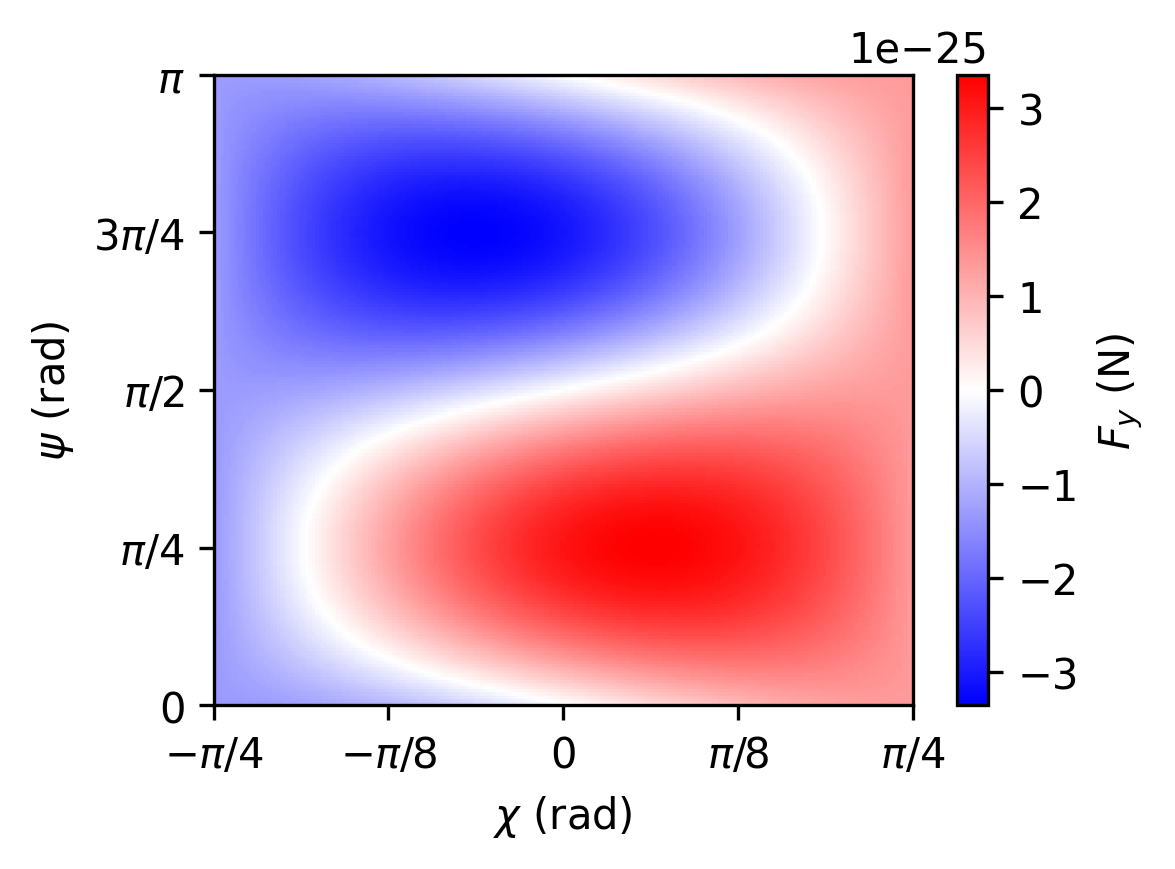

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _to_numeric(value, unit=None):
    if hasattr(value, "to"):
        return value.to(unit).magnitude if unit else value.magnitude
    if hasattr(value, "magnitude"):
        return value.magnitude
    return float(value)

sweep_par_x = 'chi'
sweep_par_y = 'psi'

heatmap_r_psi = df_sweep_chi_psi.copy()
heatmap_r_psi[sweep_par_x+"_rad"] = heatmap_r_psi[sweep_par_x].apply(_to_numeric)
heatmap_r_psi[sweep_par_y+"_rad"] = heatmap_r_psi[sweep_par_y].apply(_to_numeric)
heatmap_r_psi["Fy_N_full"] = heatmap_r_psi["Fy"].apply(lambda v: _to_numeric(v, "newton"))
heatmap_r_psi["Fy_N_spp"] = heatmap_r_psi["Fyspp"].apply(lambda v: _to_numeric(v, "newton"))
heatmap_r_psi["Fy_N_air"] = heatmap_r_psi["Fy_N_full"] - heatmap_r_psi["Fy_N_spp"]

plt_comp = 'tot'

if plt_comp == 'air':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_air")
elif plt_comp == 'spp':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_spp")
elif plt_comp == 'tot':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_full")
    
    
pivot_r_psi_full = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_full")
pivot_r_psi_full = pivot_r_psi_full.sort_index().sort_index(axis=1)

pivot_r_psi = pivot_r_psi.sort_index().sort_index(axis=1)

vmax = np.nanmax(np.abs(pivot_r_psi_full.values)) or 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
im = ax.imshow(
    pivot_r_psi.values,
    origin="lower",
    aspect="auto",
    extent=[pivot_r_psi.columns.min(), pivot_r_psi.columns.max(), pivot_r_psi.index.min(), pivot_r_psi.index.max()],
    cmap="bwr",
    norm=norm,
)

cbar = plt.colorbar(im, ax=ax, label="$F_y$ (N)")
ax.set_xlabel(f"$\\{sweep_par_x}$ (rad)")
ax.set_ylabel(f"$\\{sweep_par_y}$ (rad)")
# ax.set_title(f"$F_y^{{{plt_comp}}}$ vs $\\{sweep_par_x}$ and $\\{sweep_par_y}$ at $R$={base_config_R_psi.R.magnitude} nm")
ax.set_xticks([-np.pi/4,-np.pi/8, 0,np.pi/8, np.pi/4])
ax.set_xticklabels(["$-\\pi/4$", "$-\\pi/8$", "0", "$\\pi/8$", "$\\pi/4$"])

yticks = [0, np.pi/4, np.pi/2, np.pi*3/4, np.pi]
yticklabels = ["$0$", "$\\pi/4$", "$\\pi/2$", "$3 \\pi/4$", "$\\pi$"]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

plt.tight_layout()
plt.show()

MIN: chi = -0.201282946398341 psi = 2.3522477657531615 Fy = -3.3547268178543354e-25
MAX: chi = 0.201282946398341 psi = 0.7893448878366315 Fy = 3.3547268178543363e-25


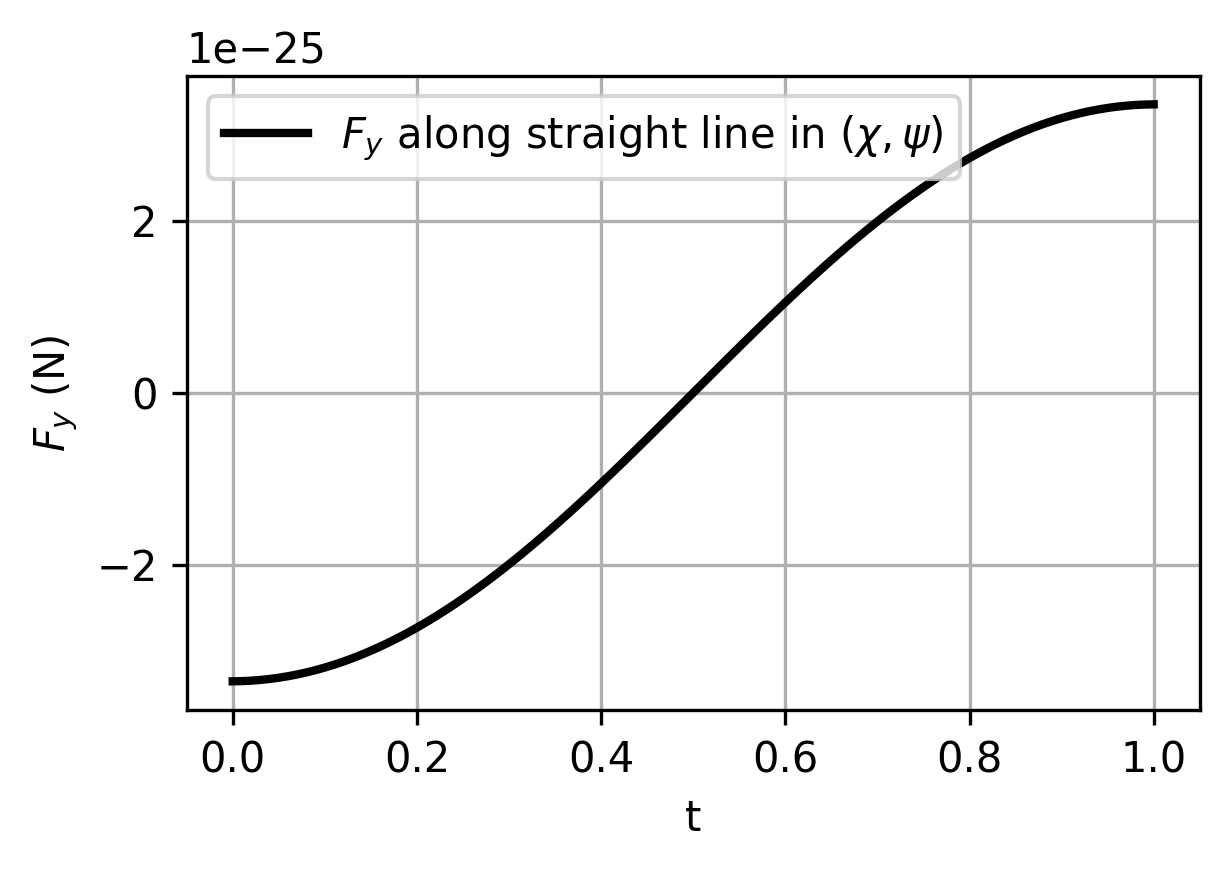

In [10]:
from matplotlib.colors import TwoSlopeNorm

pivot = pivot_r_psi.sort_index().sort_index(axis=1)

x_vals = pivot.columns.to_numpy(dtype=float)  # chi
y_vals = pivot.index.to_numpy(dtype=float)    # psi
Z = pivot.to_numpy(dtype=float)               # Fy[y_i, x_j]

flat = Z.ravel()
mask = np.isfinite(flat)

flat_masked = flat.copy()
flat_masked[~mask] = np.nan

idx_min = int(np.nanargmin(flat_masked))
idx_max = int(np.nanargmax(flat_masked))

H, W = Z.shape
iy_min, ix_min = idx_min // W, idx_min % W
iy_max, ix_max = idx_max // W, idx_max % W

chi_min, psi_min, Fy_min = x_vals[ix_min], y_vals[iy_min], Z[iy_min, ix_min]
chi_max, psi_max, Fy_max = x_vals[ix_max], y_vals[iy_max], Z[iy_max, ix_max]

print("MIN: chi =", chi_min, "psi =", psi_min, "Fy =", Fy_min)
print("MAX: chi =", chi_max, "psi =", psi_max, "Fy =", Fy_max)

N = 100
t = np.linspace(0.0, 1.0, N)
chi_line = chi_min + t * (chi_max - chi_min)
psi_line = psi_min + t * (psi_max - psi_min)

# 3) Очень простая билинейная интерполяция по регулярной сетке
def bilinear_interp_regular_grid(x_vals, y_vals, Z, xq, yq):
    xq = np.asarray(xq, dtype=float)
    yq = np.asarray(yq, dtype=float)

    ix = np.searchsorted(x_vals, xq, side="right") - 1
    iy = np.searchsorted(y_vals, yq, side="right") - 1
    ix = np.clip(ix, 0, len(x_vals) - 2)
    iy = np.clip(iy, 0, len(y_vals) - 2)

    x0 = x_vals[ix]
    x1 = x_vals[ix + 1]
    y0 = y_vals[iy]
    y1 = y_vals[iy + 1]

    tx = (xq - x0) / (x1 - x0 + 1e-300)
    ty = (yq - y0) / (y1 - y0 + 1e-300)

    z00 = Z[iy, ix]
    z10 = Z[iy, ix + 1]
    z01 = Z[iy + 1, ix]
    z11 = Z[iy + 1, ix + 1]

    z0 = z00 * (1 - tx) + z10 * tx
    z1 = z01 * (1 - tx) + z11 * tx
    z = z0 * (1 - ty) + z1 * ty
    return z

Fy_line = bilinear_interp_regular_grid(x_vals, y_vals, Z, chi_line, psi_line)

Fy_target = Fy_min + t * (Fy_max - Fy_min)

plt.figure(figsize=(4.2, 3.0), dpi=300)
plt.plot(t, Fy_line, lw=2, c="black", label=r"$F_y$ along straight line in $(\chi,\psi)$")
plt.xlabel("t")
plt.ylabel(r"$F_y$ (N)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


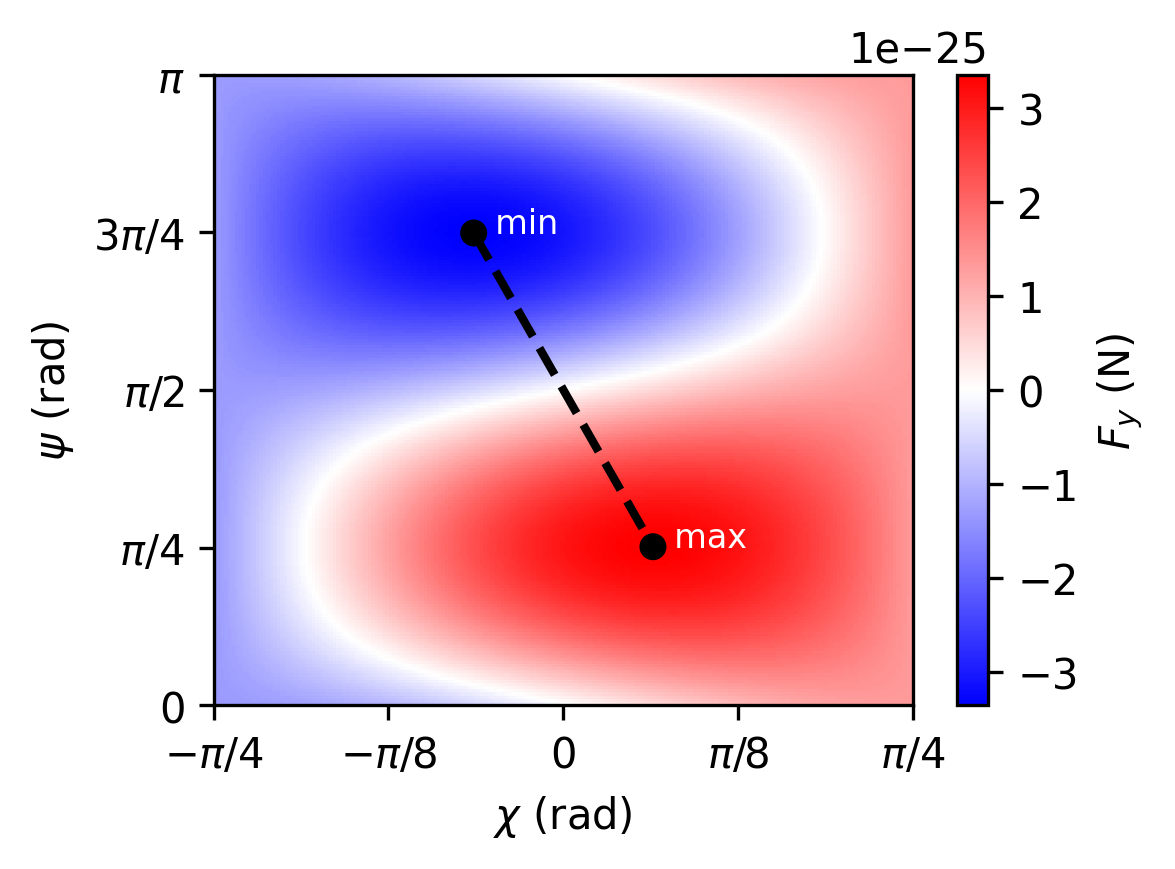

In [5]:
vmax = np.nanmax(np.abs(Z)) or 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    cmap="bwr",
    norm=norm,
)
plt.colorbar(im, ax=ax, label=r"$F_y$ (N)")

ax.plot(chi_line, psi_line, c="black", lw=2, ls='--')
ax.scatter([chi_min, chi_max], [psi_min, psi_max], c=["black", "black"], s=30, zorder=5)
ax.text(chi_min, psi_min, "  min", color="white", fontsize=8)
ax.text(chi_max, psi_max, "  max", color="white", fontsize=8)

ax.set_xlabel(r"$\chi$ (rad)")
ax.set_ylabel(r"$\psi$ (rad)")

ax.set_xticks([-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4])
ax.set_xticklabels([r"$-\pi/4$", r"$-\pi/8$", "0", r"$\pi/8$", r"$\pi/4$"])
yticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
yticklabels = [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
plt.tight_layout()
plt.show()

unique grid points on line: 100


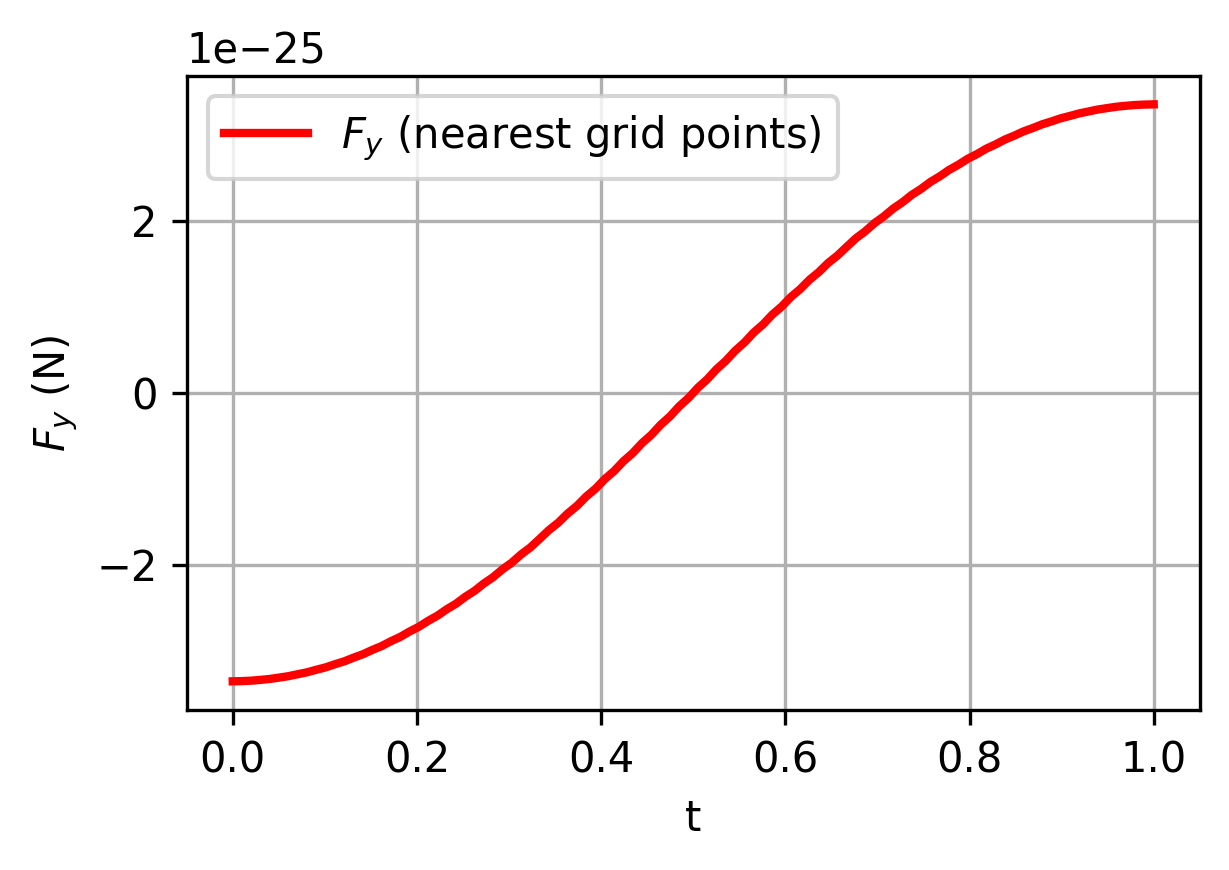

In [ ]:
def nearest_index(sorted_vals: np.ndarray, q: np.ndarray) -> np.ndarray:
    """Для каждого q возвращает индекс ближайшего элемента в sorted_vals (sorted asc)."""
    q = np.asarray(q, dtype=float)
    j = np.searchsorted(sorted_vals, q)
    j = np.clip(j, 1, len(sorted_vals) - 1)
    left = sorted_vals[j - 1]
    right = sorted_vals[j]
    return np.where(np.abs(q - left) <= np.abs(q - right), j - 1, j).astype(int)

ix = nearest_index(x_vals, chi_line)
iy = nearest_index(y_vals, psi_line)

keep = np.ones_like(ix, dtype=bool)
keep[1:] = (ix[1:] != ix[:-1]) | (iy[1:] != iy[:-1])
ix_u = ix[keep]
iy_u = iy[keep]
t_u = t[keep]

chi_u = x_vals[ix_u]
psi_u = y_vals[iy_u]
Fy_u = Z[iy_u, ix_u]

print("unique grid points on line:", len(Fy_u))

plt.figure(figsize=(4.2, 3.0), dpi=300)
plt.plot(t_u, Fy_u, lw=2, c="red", label=r"$F_y$ (nearest grid points)")
plt.xlabel("t")
plt.ylabel(r"$F_y$ (N)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


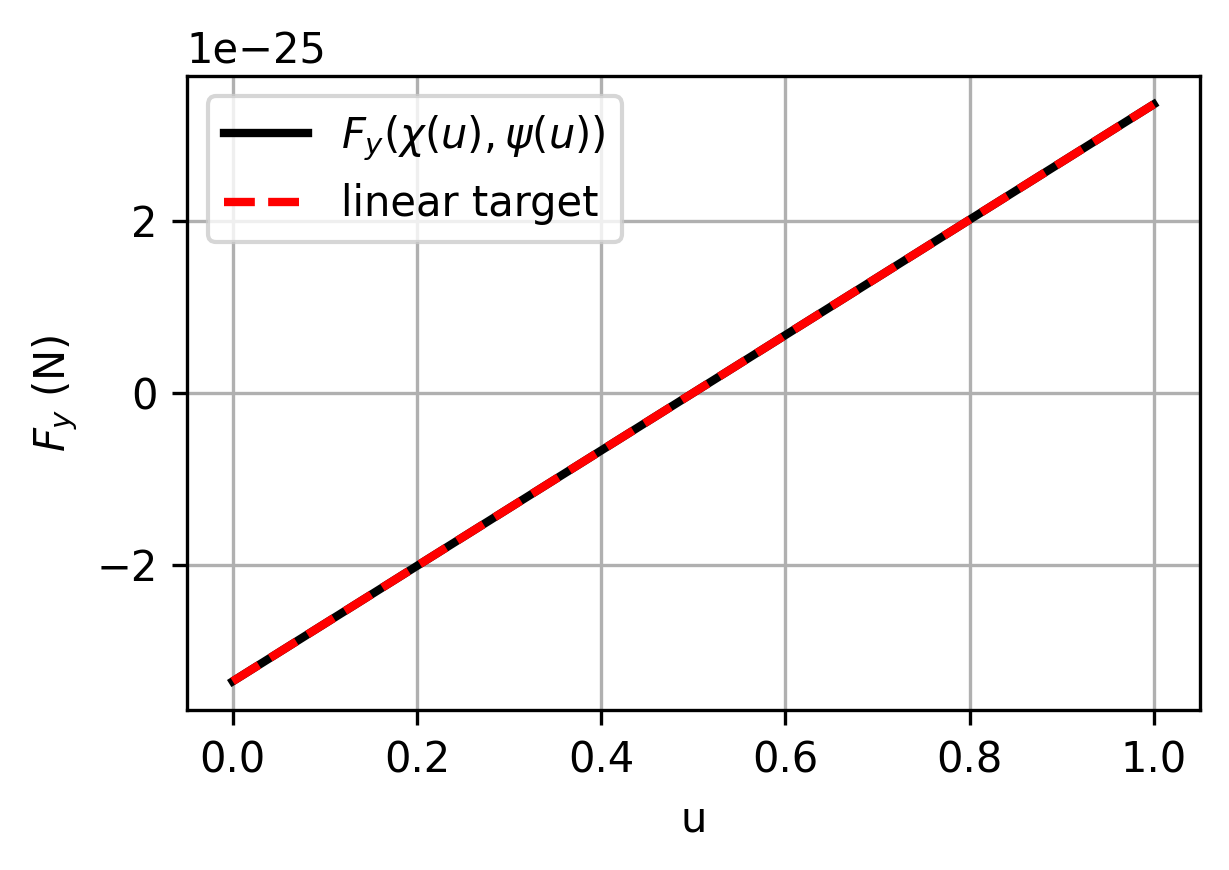

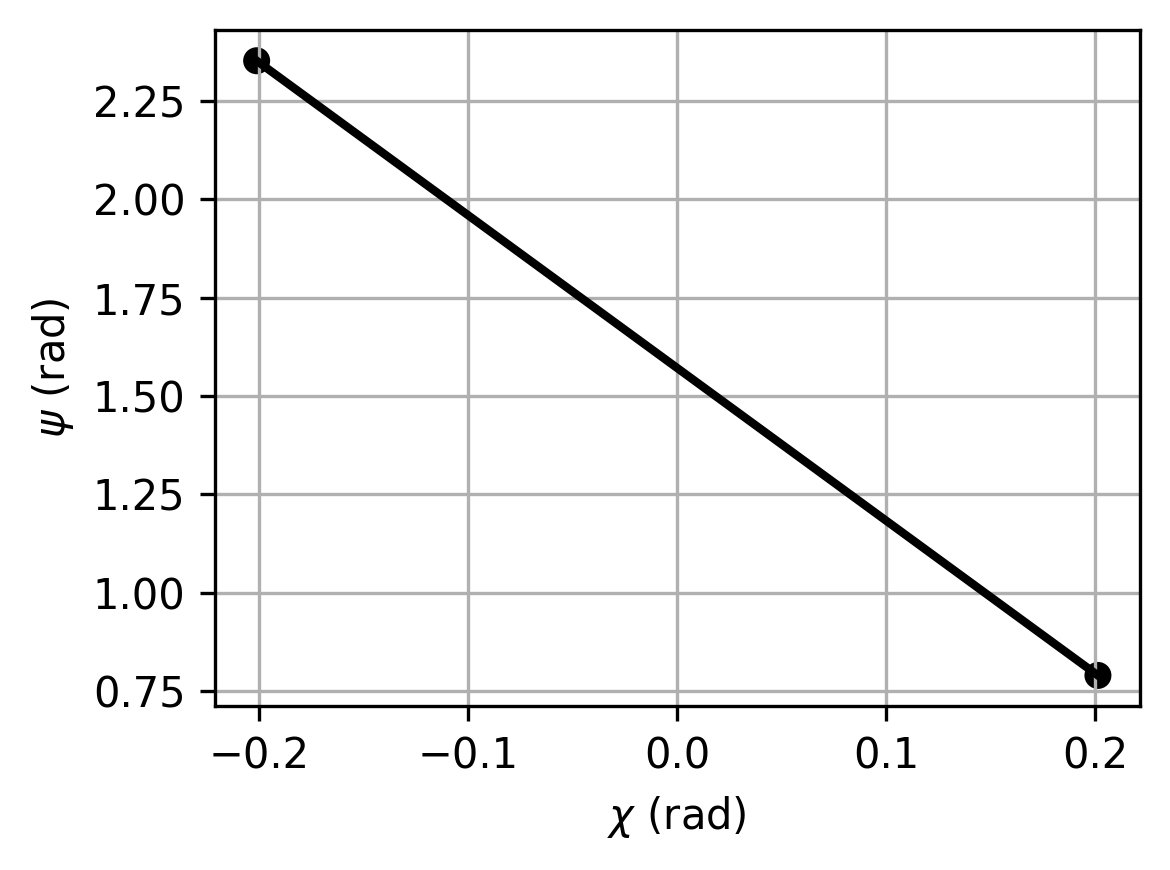

In [7]:
def smoothstep(t):
    t = np.asarray(t, dtype=float)
    return t * t * (3.0 - 2.0 * t)

# 1) Гладкая траектория между (chi_min, psi_min) и (chi_max, psi_max)
N = 400
t = np.linspace(0.0, 1.0, N)
s = smoothstep(t)

chi_path = chi_min + s * (chi_max - chi_min)
psi_path = psi_min + s * (psi_max - psi_min)

# 2) Fy вдоль траектории (используйте вашу билинейную интерполяцию на регулярной сетке)
Fy_path = bilinear_interp_regular_grid(x_vals, y_vals, Z, chi_path, psi_path)

# 3) Перепараметризация: u = нормированный Fy (получится "линеаризация" по u)
Fy0 = float(Fy_path[0])
Fy1 = float(Fy_path[-1])
den = (Fy1 - Fy0) if abs(Fy1 - Fy0) > 0 else 1.0
u_raw = (Fy_path - Fy0) / den

# Важно: np.interp требует монотонный x. Упорядочим по u_raw и уберём повторы.
order = np.argsort(u_raw)
u_sorted = u_raw[order]
t_sorted = t[order]

u_unique, idx_unique = np.unique(u_sorted, return_index=True)
t_unique = t_sorted[idx_unique]

# Строим "новый" параметр u равномерно => Fy(u) будет близко к линейному
u = np.linspace(0.0, 1.0, N)
t_of_u = np.interp(u, u_unique, t_unique)

# Итоговые гладкие chi(u), psi(u)
s_u = smoothstep(t_of_u)
chi_u = chi_min + s_u * (chi_max - chi_min)
psi_u = psi_min + s_u * (psi_max - psi_min)

Fy_u = bilinear_interp_regular_grid(x_vals, y_vals, Z, chi_u, psi_u)
Fy_target = Fy0 + u * (Fy1 - Fy0)

# Диагностика: насколько близко к линейному
plt.figure(figsize=(4.2, 3.0), dpi=300)
plt.plot(u, Fy_u, c="black", lw=2, label=r"$F_y(\chi(u),\psi(u))$")
plt.plot(u, Fy_target, c="red", lw=2, ls="--", label="linear target")
plt.xlabel("u")
plt.ylabel(r"$F_y$ (N)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Визуализация гладкого пути в (chi, psi)
plt.figure(figsize=(4.0, 3.0), dpi=300)
plt.plot(chi_u, psi_u, c="black", lw=2)
plt.scatter([chi_min, chi_max], [psi_min, psi_max], c=["black", "black"], s=30)
plt.xlabel(r"$\chi$ (rad)")
plt.ylabel(r"$\psi$ (rad)")
plt.grid(True)
plt.tight_layout()
plt.show()
# ...existing code...

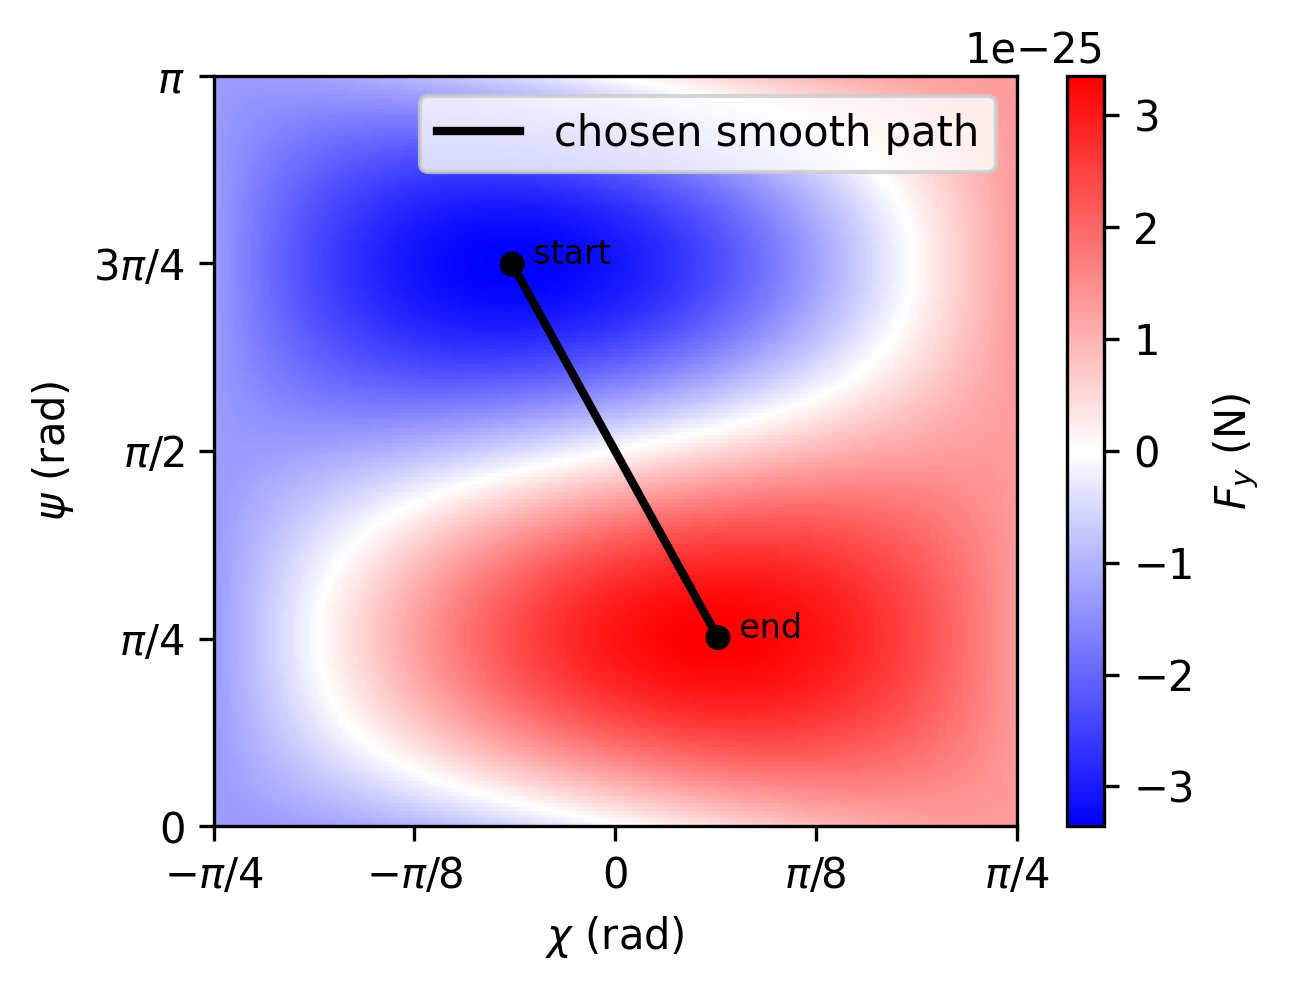

In [8]:
from matplotlib.colors import TwoSlopeNorm


vmax = np.nanmax(np.abs(Z)) or 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=300)

im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[float(x_vals.min()), float(x_vals.max()), float(y_vals.min()), float(y_vals.max())],
    cmap="bwr",
    norm=norm,
)

ax.plot(chi_u, psi_u, c="black", lw=2.0, label="chosen smooth path")

ax.scatter([chi_u[0], chi_u[-1]], [psi_u[0], psi_u[-1]], c=["black", "black"], s=25, zorder=5)
ax.text(chi_u[0],  psi_u[0],  "  start", color="black", fontsize=8)
ax.text(chi_u[-1], psi_u[-1], "  end",   color="black", fontsize=8)

cbar = plt.colorbar(im, ax=ax, label=r"$F_y$ (N)")

ax.set_xlabel(r"$\chi$ (rad)")
ax.set_ylabel(r"$\psi$ (rad)")

ax.set_xticks([-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4])
ax.set_xticklabels([r"$-\pi/4$", r"$-\pi/8$", "0", r"$\pi/8$", r"$\pi/4$"])
yticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
ax.set_yticks(yticks)
ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


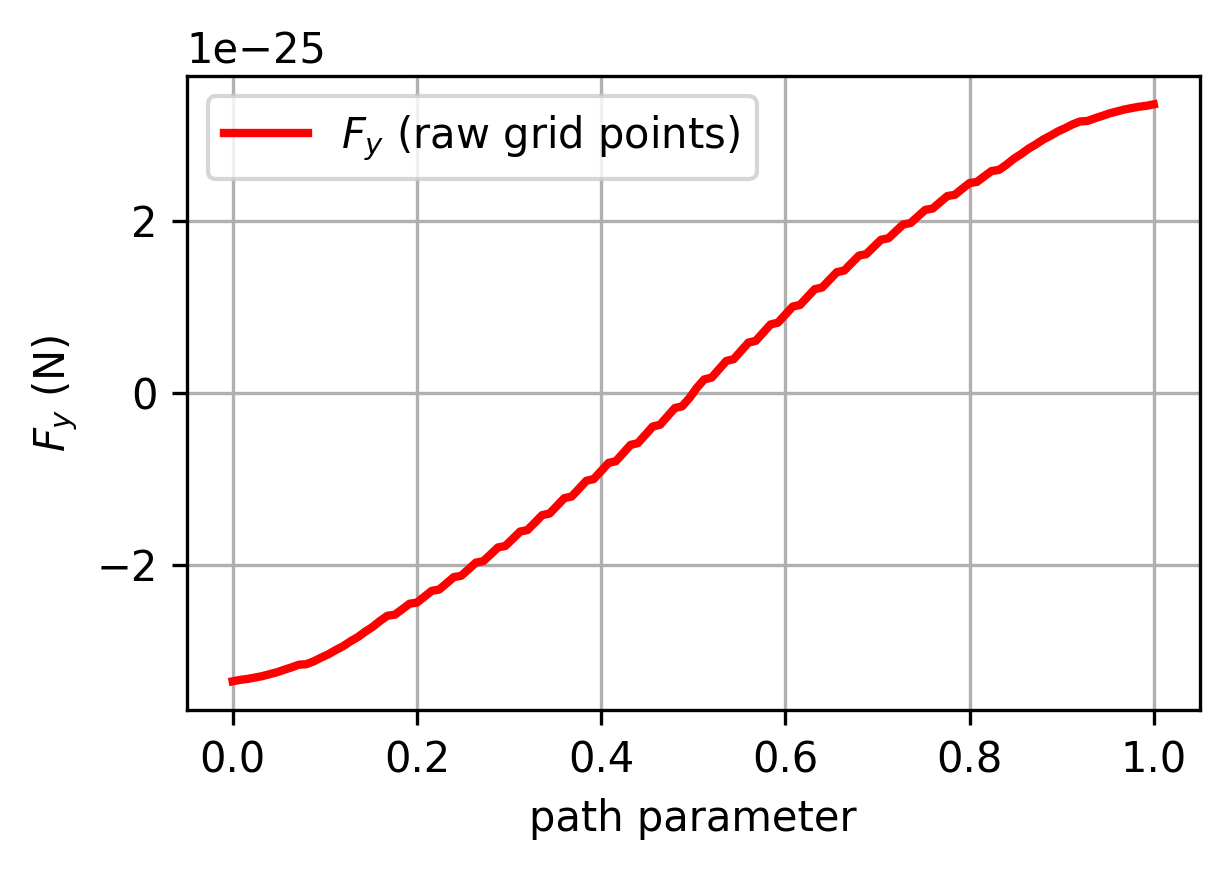

,s,chi,psi,Fy
0,0.000,-0.201283,2.352248,-3.354727e-25
1,0.008,-0.185496,2.304887,-3.337836e-25
2,0.016,-0.185496,2.289100,-3.327115e-25
3,0.024,-0.177603,2.273313,-3.311135e-25
4,0.032,-0.177603,2.257526,-3.294650e-25
5,0.040,-0.169709,2.241739,-3.271889e-25
6,0.048,-0.169709,2.225953,-3.249643e-25
7,0.056,-0.161816,2.210166,-3.220073e-25
8,0.064,-0.161816,2.194379,-3.192098e-25
9,0.072,-0.161816,2.178592,-3.161360e-25


In [9]:
# ...existing code...

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Используем RAW-данные из датафрейма через pivot (это не интерполяция)
pivot_raw = pivot_r_psi.sort_index().sort_index(axis=1)
x_vals = pivot_raw.columns.to_numpy(dtype=float)  # chi grid
y_vals = pivot_raw.index.to_numpy(dtype=float)    # psi grid
Z = pivot_raw.to_numpy(dtype=float)               # Fy grid, raw from df

def nearest_index(sorted_vals: np.ndarray, q: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    j = np.searchsorted(sorted_vals, q)
    j = np.clip(j, 1, len(sorted_vals) - 1)
    left = sorted_vals[j - 1]
    right = sorted_vals[j]
    return np.where(np.abs(q - left) <= np.abs(q - right), j - 1, j).astype(int)

# "Прищёлкиваем" гладкий путь (chi_u, psi_u) к ближайшим узлам сетки
ix = nearest_index(x_vals, chi_u)
iy = nearest_index(y_vals, psi_u)

# (опционально) убираем подряд идущие дубликаты узлов, чтобы график не “перерисовывал” одну точку
keep = np.ones_like(ix, dtype=bool)
keep[1:] = (ix[1:] != ix[:-1]) | (iy[1:] != iy[:-1])

ix_g = ix[keep]
iy_g = iy[keep]

chi_g = x_vals[ix_g]
psi_g = y_vals[iy_g]
Fy_g = Z[iy_g, ix_g]  # <-- строго raw (без интерполяции)

# Параметр для графика (равномерный по пути; можно заменить на ваш u, если хотите)
s = np.linspace(0.0, 1.0, len(Fy_g))

plt.figure(figsize=(4.2, 3.0), dpi=300)
plt.plot(s, Fy_g, c="red", lw=2, label=r"$F_y$ (raw grid points)")
plt.xlabel("path parameter")
plt.ylabel(r"$F_y$ (N)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# (опционально) показать реальные выбранные (chi, psi) из сетки и значения Fy таблицей
df_chosen = pd.DataFrame({"s": s, "chi": chi_g, "psi": psi_g, "Fy": Fy_g})
display(df_chosen.head(15))

# ...existing code...

# Figure 4

# Task - calculate the time of particle moving out of the circle under constatn optical force from plane wave (in free space) in water madia 